# 02 — Analyze

**Takes in:** `data/analysis_sample.csv` from `01_merge.ipynb`.

**Does:** describes mobility across density categories; estimates adjusted rural associations using commuting-zone fixed effects and commuting-zone-clustered standard errors; checks a minimum-child-count sample; and compares rural with dense-urban estimates.

**Outputs:** three figures and four LaTeX tables in `output/`.

In [10]:
import importlib
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath("."))
import utils
importlib.reload(utils)

<module 'utils' from '/Users/maxfortner/Documents/Dartmouth/QSS20/qss20-rural-mobility/code/utils.py'>

## Functions

In [11]:
def style_axes(ax):
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(utils.GRID)
    ax.tick_params(colors=utils.INK_MUTED, length=0)


def fit_adjusted_ols(data, outcome, predictors, label, scale=None):
    """OLS with CZ fixed effects and CZ-clustered SEs.

    By default predictors are standardized within `data`. Pass common means and
    SDs as `scale` when coefficients must be compared across samples.
    """
    needed = [outcome, "cz"] + list(predictors)
    complete = data[needed].dropna().copy()
    means, sds = scale if scale is not None else (complete[predictors].mean(), complete[predictors].std())
    z = (complete[predictors] - means) / sds
    cz_fe = pd.get_dummies(complete["cz"].astype(str), prefix="cz", drop_first=True, dtype=float)
    fe_only = sm.add_constant(cz_fe.reset_index(drop=True)).astype(float)
    X = pd.concat([z.reset_index(drop=True), cz_fe.reset_index(drop=True)], axis=1)
    X = sm.add_constant(X).astype(float)
    model = sm.OLS(complete[outcome].to_numpy(), X).fit(
        cov_type="cluster", cov_kwds={"groups": complete["cz"].to_numpy()})
    fe_model = sm.OLS(complete[outcome].to_numpy(), fe_only).fit()
    delta_r2 = model.rsquared - fe_model.rsquared
    print("{}: {:,} complete cases of {:,}; {:,} CZs; R-squared = {:.3f}; delta R-squared = {:.3f}".format(
        label, len(complete), len(data), complete["cz"].nunique(), model.rsquared, delta_r2))
    return model, complete, delta_r2


def coef_frame(model, labels):
    ci = model.conf_int()
    rows = []
    for term, label in labels.items():
        rows.append({"term": term, "label": label, "beta": model.params[term],
                     "lo": ci.loc[term, 0], "hi": ci.loc[term, 1],
                     "pval": model.pvalues[term]})
    return pd.DataFrame(rows).sort_values("beta")


def fig1_mobility_by_density(data, out_path):
    order = [c for c in utils.DENSITY_LABELS if c in set(data["density_cat"].dropna())]
    groups = [data.loc[data["density_cat"] == c, utils.MOBILITY_VAR].dropna().values for c in order]
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    bp = ax.boxplot(groups, patch_artist=True, widths=0.55, showfliers=False,
                    whis=(5, 95), medianprops=dict(color="white", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(utils.BLUE); patch.set_edgecolor("white"); patch.set_linewidth(2)
    for element in ["whiskers", "caps"]:
        for line in bp[element]: line.set_color(utils.INK_MUTED); line.set_linewidth(1)
    national_median = data[utils.MOBILITY_VAR].median()
    ax.axhline(national_median, color=utils.INK_MUTED, linestyle="--", linewidth=1)
    ax.text(len(order) + .45, national_median, "National median", va="center", ha="right",
            fontsize=7.5, color=utils.INK_MUTED, backgroundcolor="white")
    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels(["{}\nn={:,}".format(c, len(g)) for c, g in zip(order, groups)], fontsize=8.2)
    ax.set_ylabel("Mean adult household-income rank\n(children of p25 parents)", fontsize=9)
    ax.set_xlabel("Population density in 2000 (people per sq. mi.)", fontsize=9)
    ax.set_title("Within-category mobility variation exceeds median differences", loc="left", fontsize=11, pad=28)
    ax.text(0, 1.01, "Boxes show IQR; whiskers show 5th–95th percentiles", transform=ax.transAxes,
            fontsize=8, color=utils.INK_MUTED)
    ax.set_ylim(.20, .65); ax.yaxis.grid(True, color=utils.GRID, linewidth=.8); style_axes(ax)
    fig.tight_layout(); fig.savefig(out_path, dpi=200, facecolor="white"); return fig


def coefficient_plot(coefs, out_path, title, note):
    ordered = coefs.sort_values("beta")
    y = np.arange(len(ordered))
    colors = [utils.BLUE if value > 0 else utils.ORANGE for value in ordered["beta"]]
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    ax.hlines(y, ordered["lo"], ordered["hi"], color=colors, linewidth=2, alpha=.55)
    ax.scatter(ordered["beta"], y, color=colors, s=34, zorder=3)
    ax.axvline(0, color=utils.INK_MUTED, linestyle="--", linewidth=1)
    ax.set_yticks(y); ax.set_yticklabels(ordered["label"], fontsize=8.7)
    ax.set_xlabel("Adjusted income-rank association per predictor SD (95% CI)", fontsize=9)
    ax.set_title(title, loc="left", fontsize=11, pad=52)
    ax.text(0, 1.01, note, transform=ax.transAxes, fontsize=7.4, color=utils.INK_MUTED, linespacing=1.35)
    ax.xaxis.grid(True, color=utils.GRID, linewidth=.8); style_axes(ax)
    fig.tight_layout(); fig.savefig(out_path, dpi=200, facecolor="white"); return fig


def rural_dense_plot(rural_coefs, dense_coefs, out_path):
    joined = rural_coefs[["term", "label", "beta", "lo", "hi"]].merge(
        dense_coefs[["term", "beta", "lo", "hi"]], on="term", suffixes=("_rural", "_dense"))
    joined = joined.sort_values("beta_rural"); y = np.arange(len(joined))
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    for suffix, offset, color, label in [("rural", -.12, utils.BLUE, "Rural (<100)"),
                                          ("dense", .12, utils.ORANGE, "Dense urban (10k+)")]:
        ax.hlines(y + offset, joined["lo_" + suffix], joined["hi_" + suffix], color=color, alpha=.55, linewidth=2)
        ax.scatter(joined["beta_" + suffix], y + offset, color=color, s=28, label=label, zorder=3)
    ax.axvline(0, color=utils.INK_MUTED, linestyle="--", linewidth=1)
    ax.set_yticks(y); ax.set_yticklabels(joined["label"], fontsize=8.7)
    ax.set_xlabel("Adjusted income-rank association per common pooled SD (95% CI)", fontsize=8.5)
    ax.set_title("Same-scale rural and dense-urban associations", loc="left", fontsize=11, pad=40)
    ax.text(0, 1.01, "Both groups use pooled rural+dense-urban SDs; CZ-clustered intervals\nDense-urban inference uses only 28 CZ clusters and should be treated as exploratory", transform=ax.transAxes, fontsize=7.4, color=utils.INK_MUTED, linespacing=1.35)
    ax.legend(frameon=False, fontsize=8, loc="lower right"); ax.xaxis.grid(True, color=utils.GRID, linewidth=.8); style_axes(ax)
    fig.tight_layout(); fig.savefig(out_path, dpi=200, facecolor="white"); return fig


def write_sample_table(data, out_path):
    rural = data[data["popdensity2000"] < utils.RURAL_CUTOFF]
    rows = [("Census tracts in analysis sample", "{:,}".format(len(data))),
            (r"Rural tracts ($<$100 people/sq.\ mi.)", "{:,}".format(len(rural))),
            ("Commuting zones represented", "{:,}".format(data["cz"].nunique())),
            ("Median tract mobility (income rank)", "{:.3f}".format(data[utils.MOBILITY_VAR].median())),
            (r"Std.\ dev.\ of tract mobility", "{:.3f}".format(data[utils.MOBILITY_VAR].std())),
            ("Median children per tract estimate", "{:,.0f}".format(data[utils.COUNT_VAR].median()))]
    lines = ["\\begin{tabular}{lr}", "\\toprule", "Analysis sample & Value \\\\", "\\midrule"]
    lines += ["{} & {} \\\\".format(k, v) for k, v in rows]
    lines += ["\\bottomrule", "\\end{tabular}"]
    with open(out_path, "w") as handle: handle.write("\n".join(lines) + "\n")


def write_coef_table(coefs, model, out_path):
    lines = ["\\begin{tabular}{lrrr}", "\\toprule",
             "Characteristic (per SD) & $\\beta$ & 95\\% CI & $p$ \\\\", "\\midrule"]
    for _, row in coefs.sort_values("beta").iterrows():
        p = "$<0.001$" if row["pval"] < .001 else "{:.3f}".format(row["pval"])
        lines.append("{} & {:.4f} & [{:.4f}, {:.4f}] & {} \\\\".format(
            row["label"], row["beta"], row["lo"], row["hi"], p))
    lines += ["\\midrule", "N & \\multicolumn{{3}}{{r}}{{{:,}}} \\\\".format(int(model.nobs)),
              "$R^2$ & \\multicolumn{{3}}{{r}}{{{:.3f}}} \\\\".format(model.rsquared),
              "\\bottomrule", "\\end{tabular}"]
    with open(out_path, "w") as handle: handle.write("\n".join(lines) + "\n")


def write_sensitivity_table(main_coefs, screened_coefs, out_path):
    tab = main_coefs[["term", "label", "beta"]].merge(
        screened_coefs[["term", "beta"]], on="term", suffixes=("_all", "_screened"))
    lines = ["\\begin{tabular}{lrr}", "\\toprule",
             "Characteristic & All complete cases & Count $\\geq$ 200 \\\\", "\\midrule"]
    for _, row in tab.sort_values("beta_all").iterrows():
        lines.append("{} & {:.4f} & {:.4f} \\\\".format(row["label"], row["beta_all"], row["beta_screened"]))
    lines += ["\\bottomrule", "\\end{tabular}"]
    with open(out_path, "w") as handle: handle.write("\n".join(lines) + "\n")

## Load and describe the analysis sample

loaded analysis sample: 71,958 tracts


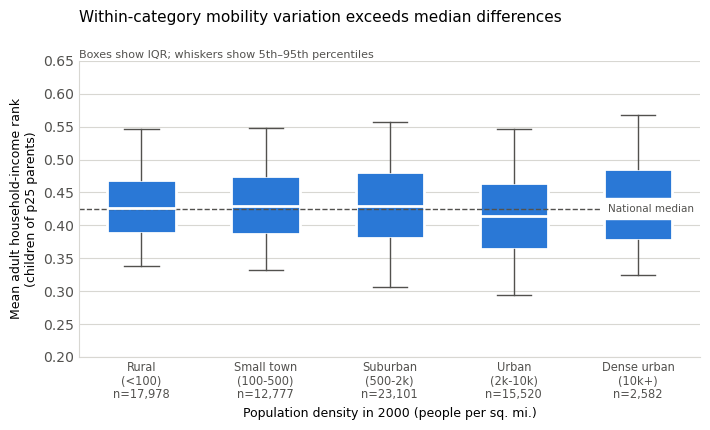

In [12]:
df = pd.read_csv(utils.data_path("analysis_sample.csv"))
predictors = list(utils.COVARIATES)
print("loaded analysis sample: {:,} tracts".format(len(df)))
fig1_mobility_by_density(df, utils.output_path("fig1_mobility_by_density.png"));

The category medians are close relative to the distributions within each category. This motivates studying heterogeneity among rural tracts rather than treating rurality itself as an explanation. The density cutoff is a transparent project definition, not the Census Bureau's official rural classification.

## Main rural model

The model compares tracts within the same commuting zone, reducing confounding by broad regional differences. Confidence intervals allow arbitrary residual correlation among tracts in a commuting zone. These remain descriptive conditional associations, not causal effects.

rural main model: 17,310 complete cases of 17,978; 727 CZs; R-squared = 0.661; delta R-squared = 0.097


,term,label,beta,lo,hi,pval
0,singleparent_share2000,Share single-parent households,-0.015125,-0.016887,-0.013363,1.599634e-63
6,hhinc_mean2000,Mean household income,-0.000655,-0.003099,0.001789,5.993711e-01
3,ann_avg_job_growth_2004_2013,"Annual job growth, 2004-13",0.000213,-0.000499,0.000924,5.578978e-01
2,mean_commutetime2000,Mean commute time,0.000426,-0.000768,0.001621,4.841106e-01
7,emp2000,Share of adults employed,0.000480,-0.000895,0.001855,4.936250e-01
5,gsmn_math_g3_2013,Mean 3rd-grade math score,0.002863,0.001685,0.004041,1.895133e-06
4,mail_return_rate2010,Census mail return rate,0.002916,0.001642,0.004191,7.302769e-06
1,poor_share2000,Share below poverty line,0.003825,0.002229,0.005422,2.657806e-06
8,frac_coll_plus2000,Share with a BA or higher,0.007428,0.005711,0.009145,2.273444e-17
9,share_white2000,Share white,0.011539,0.009871,0.013206,6.734892e-42


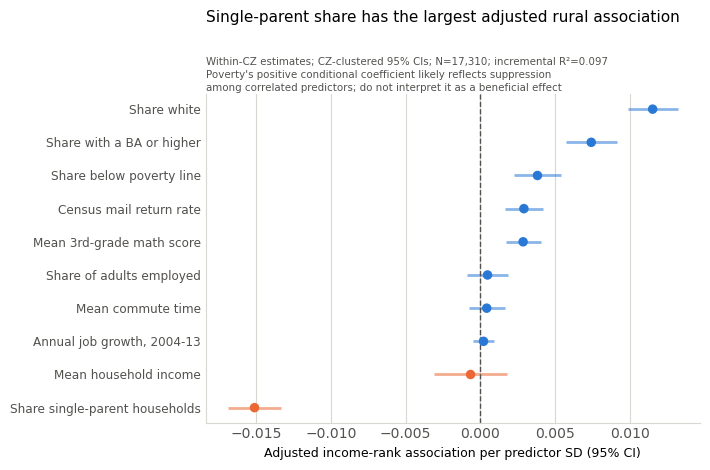

In [13]:
rural = df[df["popdensity2000"] < utils.RURAL_CUTOFF].copy()
main_model, main_sample, main_delta_r2 = fit_adjusted_ols(rural, utils.MOBILITY_VAR, predictors, "rural main model")
main_coefs = coef_frame(main_model, utils.COVARIATES)
coefficient_plot(main_coefs, utils.output_path("fig2_rural_ols_coefficients.png"),
                 "Single-parent share has the largest adjusted rural association",
                 "Within-CZ estimates; CZ-clustered 95% CIs; N={:,}; incremental R²={:.3f}\nPoverty's positive conditional coefficient likely reflects suppression\namong correlated predictors; do not interpret it as a beneficial effect".format(
                     int(main_model.nobs), main_delta_r2));
main_coefs

## Precision sensitivity

Opportunity Atlas tract estimates rest on different numbers of children. The sensitivity model excludes estimates based on fewer than 200 children; this threshold is declared in `utils.py` so it can be changed transparently. Agreement in sign and magnitude is more informative than changes in significance alone.

In [14]:
screened = rural[rural[utils.COUNT_VAR] >= utils.MIN_CHILD_COUNT].copy()
screened_model, screened_sample, screened_delta_r2 = fit_adjusted_ols(screened, utils.MOBILITY_VAR, predictors, "count-screened rural model")
screened_coefs = coef_frame(screened_model, utils.COVARIATES)
sensitivity = main_coefs[["term", "label", "beta"]].merge(
    screened_coefs[["term", "beta"]], on="term", suffixes=("_all", "_screened"))
sensitivity["same_sign"] = np.sign(sensitivity["beta_all"]) == np.sign(sensitivity["beta_screened"])
sensitivity

count-screened rural model: 14,741 complete cases of 15,186; 726 CZs; R-squared = 0.730; delta R-squared = 0.081


,term,label,beta_all,beta_screened,same_sign
0,singleparent_share2000,Share single-parent households,-0.015125,-0.015714,True
1,hhinc_mean2000,Mean household income,-0.000655,-0.003169,True
2,ann_avg_job_growth_2004_2013,"Annual job growth, 2004-13",0.000213,-0.000133,False
3,mean_commutetime2000,Mean commute time,0.000426,-0.000248,False
4,emp2000,Share of adults employed,0.000480,-0.000465,False
5,gsmn_math_g3_2013,Mean 3rd-grade math score,0.002863,0.002812,True
6,mail_return_rate2010,Census mail return rate,0.002916,0.001903,True
7,poor_share2000,Share below poverty line,0.003825,0.002261,True
8,frac_coll_plus2000,Share with a BA or higher,0.007428,0.004925,True
9,share_white2000,Share white,0.011539,0.011436,True


## Rural versus dense urban

For a valid visual comparison, both models use predictor standard deviations calculated from the pooled rural and dense-urban sample. The plot remains descriptive: overlapping intervals are not a formal test of coefficient equality. Dense-urban inference is especially tentative because it contains only 28 commuting-zone clusters, below the range where conventional cluster-robust intervals are most reliable.

rural comparison model: 17,310 complete cases of 17,978; 727 CZs; R-squared = 0.661; delta R-squared = 0.097
dense-urban model: 2,468 complete cases of 2,582; 28 CZs; R-squared = 0.711; delta R-squared = 0.584


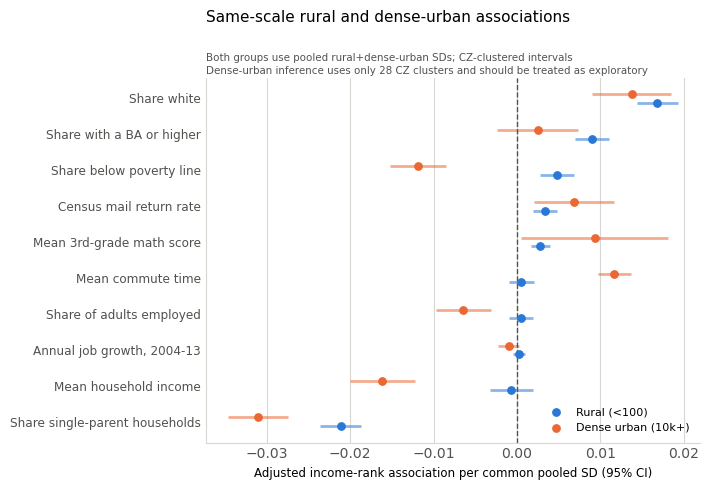

In [15]:
dense = df[df["popdensity2000"] >= utils.DENSE_URBAN_CUTOFF].copy()
comparison_pool = pd.concat([rural, dense], ignore_index=True)
comparison_complete = comparison_pool[predictors].dropna()
common_scale = (comparison_complete.mean(), comparison_complete.std())
rural_comparison_model, _, _ = fit_adjusted_ols(
    rural, utils.MOBILITY_VAR, predictors, "rural comparison model", scale=common_scale)
dense_model, dense_sample, dense_delta_r2 = fit_adjusted_ols(
    dense, utils.MOBILITY_VAR, predictors, "dense-urban model", scale=common_scale)
rural_comparison_coefs = coef_frame(rural_comparison_model, utils.COVARIATES)
dense_coefs = coef_frame(dense_model, utils.COVARIATES)
rural_dense_plot(rural_comparison_coefs, dense_coefs, utils.output_path("fig3_rural_dense_coefficients.png"));

## Collinearity diagnostic

In [16]:
corr = main_sample[predictors].corr()
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().abs().sort_values(ascending=False)
print("largest absolute predictor correlations:")
print(pairs.head(10).to_string())

largest absolute predictor correlations:
hhinc_mean2000          frac_coll_plus2000      0.782507
poor_share2000          hhinc_mean2000          0.642735
                        emp2000                 0.627922
singleparent_share2000  poor_share2000          0.619170
poor_share2000          share_white2000         0.543076
hhinc_mean2000          emp2000                 0.516262
singleparent_share2000  share_white2000         0.510138
                        hhinc_mean2000          0.505416
poor_share2000          mail_return_rate2010    0.491881
mail_return_rate2010    share_white2000         0.490963


Strong correlations among neighborhood characteristics make individual partial coefficients sensitive to model specification. In particular, signs that differ from simple bivariate relationships should be described as conditional associations or suppression patterns—not as independent effects or dismissed as noise.

## Write tables

In [17]:
write_sample_table(df, utils.output_path("table1_analysis_sample.tex"))
write_coef_table(main_coefs, main_model, utils.output_path("table3_ols_results.tex"))
write_sensitivity_table(main_coefs, screened_coefs, utils.output_path("table4_count_sensitivity.tex"))
print("wrote analysis tables")

wrote analysis tables


## Takeaway

Among rural tracts in the same commuting zone, single-parent household share has the largest adjusted association with upward mobility: a one-SD increase is associated with a 1.5-percentile-point lower mean adult household-income rank (95% CI: 1.34 to 1.69 points lower). The estimate remains similar after excluding tracts whose mobility estimate is based on fewer than 200 children (1.6 points lower). The ten covariates add 0.097 to R² beyond commuting-zone indicators alone.

The count screen does not undermine the headline result. Job growth, commute time, and employment share cross zero only by tiny amounts, and all three were statistically indistinguishable from zero in the main model. BA share attenuates by about 34%, from 0.0074 to 0.0049, so that secondary association is less stable. The positive conditional poverty coefficient should not be interpreted as poverty improving mobility: poverty is strongly correlated with single-parent share and other disadvantage measures, making suppression a more plausible reading.

The same-scale rural–dense-urban comparison is exploratory, especially because the dense-urban sample contains only 28 commuting-zone clusters. All estimates remain descriptive associations in cross-sectional tract data; they do not isolate neighborhood effects from family sorting, and several covariates were measured after the focal cohorts' childhood years.